In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import parameters as p
import auxiliary_funcs as af 
import collisions_vec as col
import monte_carlo_vec as mc

import pickle

tau_o ions = 2123.1766532800625
ZPAR = 233.3333333333333 should match 233.33
ZPERP = 0.03055752047819377


In [4]:
NUMPARTICLES = 1e6 # 1e4, do 1e5
ISOTROPIC_SOURCE = np.vstack([np.ones(int(NUMPARTICLES)), np.linspace(-1, 1, int(NUMPARTICLES))]).T
DT = 1e-5
NUMSTEPS = int(1e6)
R=5
PHI=0.01

# TESTING TIME - DXX = 0

In [ ]:
# Mesa Dame - 48s 1e3 particles 
filename = f'loss_data/{int(NUMPARTICLES)}/mesa_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
print(filename)
loss_vel, loss_step, _, _ = mc.run_mc_nopar(ISOTROPIC_SOURCE, numsteps=NUMSTEPS, D_func=col.D_nopar, A_func=col.A_mesa, 
                                            dt=DT, R=R, Phi=PHI, nprocs=6)

with open(filename, "wb") as f:
    pickle.dump((loss_vel, loss_step), f)

In [ ]:
# no parallel - 1 min 1e3 particles
filename = f'loss_data/{int(NUMPARTICLES)}/nopar_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
loss_vel, loss_step, _, _ = mc.run_mc_nopar(ISOTROPIC_SOURCE, numsteps=NUMSTEPS, D_func=col.D_nopar, A_func=col.A_nopar, 
                                            dt=DT, R=R, Phi=PHI, nprocs=6)

with open(filename, "wb") as f:
    pickle.dump((loss_vel, loss_step), f)

# TESTING TIME - DXX =/= 0

In [ ]:
# full 3.5 minutes 1e3 particles
filename = f'loss_data/{int(NUMPARTICLES)}/full_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
loss_vel, loss_step, _ = mc.run_mc(ISOTROPIC_SOURCE, numsteps=NUMSTEPS, D_func=col.D_xxi, A_func=col.A_xxi, 
                                   dt=DT, R=R, Phi=PHI, nprocs=6)

with open(filename, "wb") as f:
    pickle.dump((loss_vel, loss_step), f)

100%|██████████| 1000000/1000000 [3:35:04<00:00, 77.49it/s] 


In [ ]:
# no geom 1.5 minutesfor 100 particles 
filename = f'loss_data/{int(NUMPARTICLES)}/nogeom_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
print(filename)
loss_vel, loss_step, _ = mc.run_mc(ISOTROPIC_SOURCE, numsteps=NUMSTEPS, D_func=col.D_xxi, A_func=col.A_nogeom, 
                                   dt=DT, R=R, Phi=PHI, nprocs=6)

with open(filename, "wb") as f:
    pickle.dump((loss_vel, loss_step), f)

test_vec/1000000/nogeom_num1000000.0_dt1e-05_steps1000000_R5_Phi0.1.pkl


 28%|██▊       | 282927/1000000 [1:43:05<4:21:17, 45.74it/s]


# PLOTTING

(538245, 2)
(348077, 2)


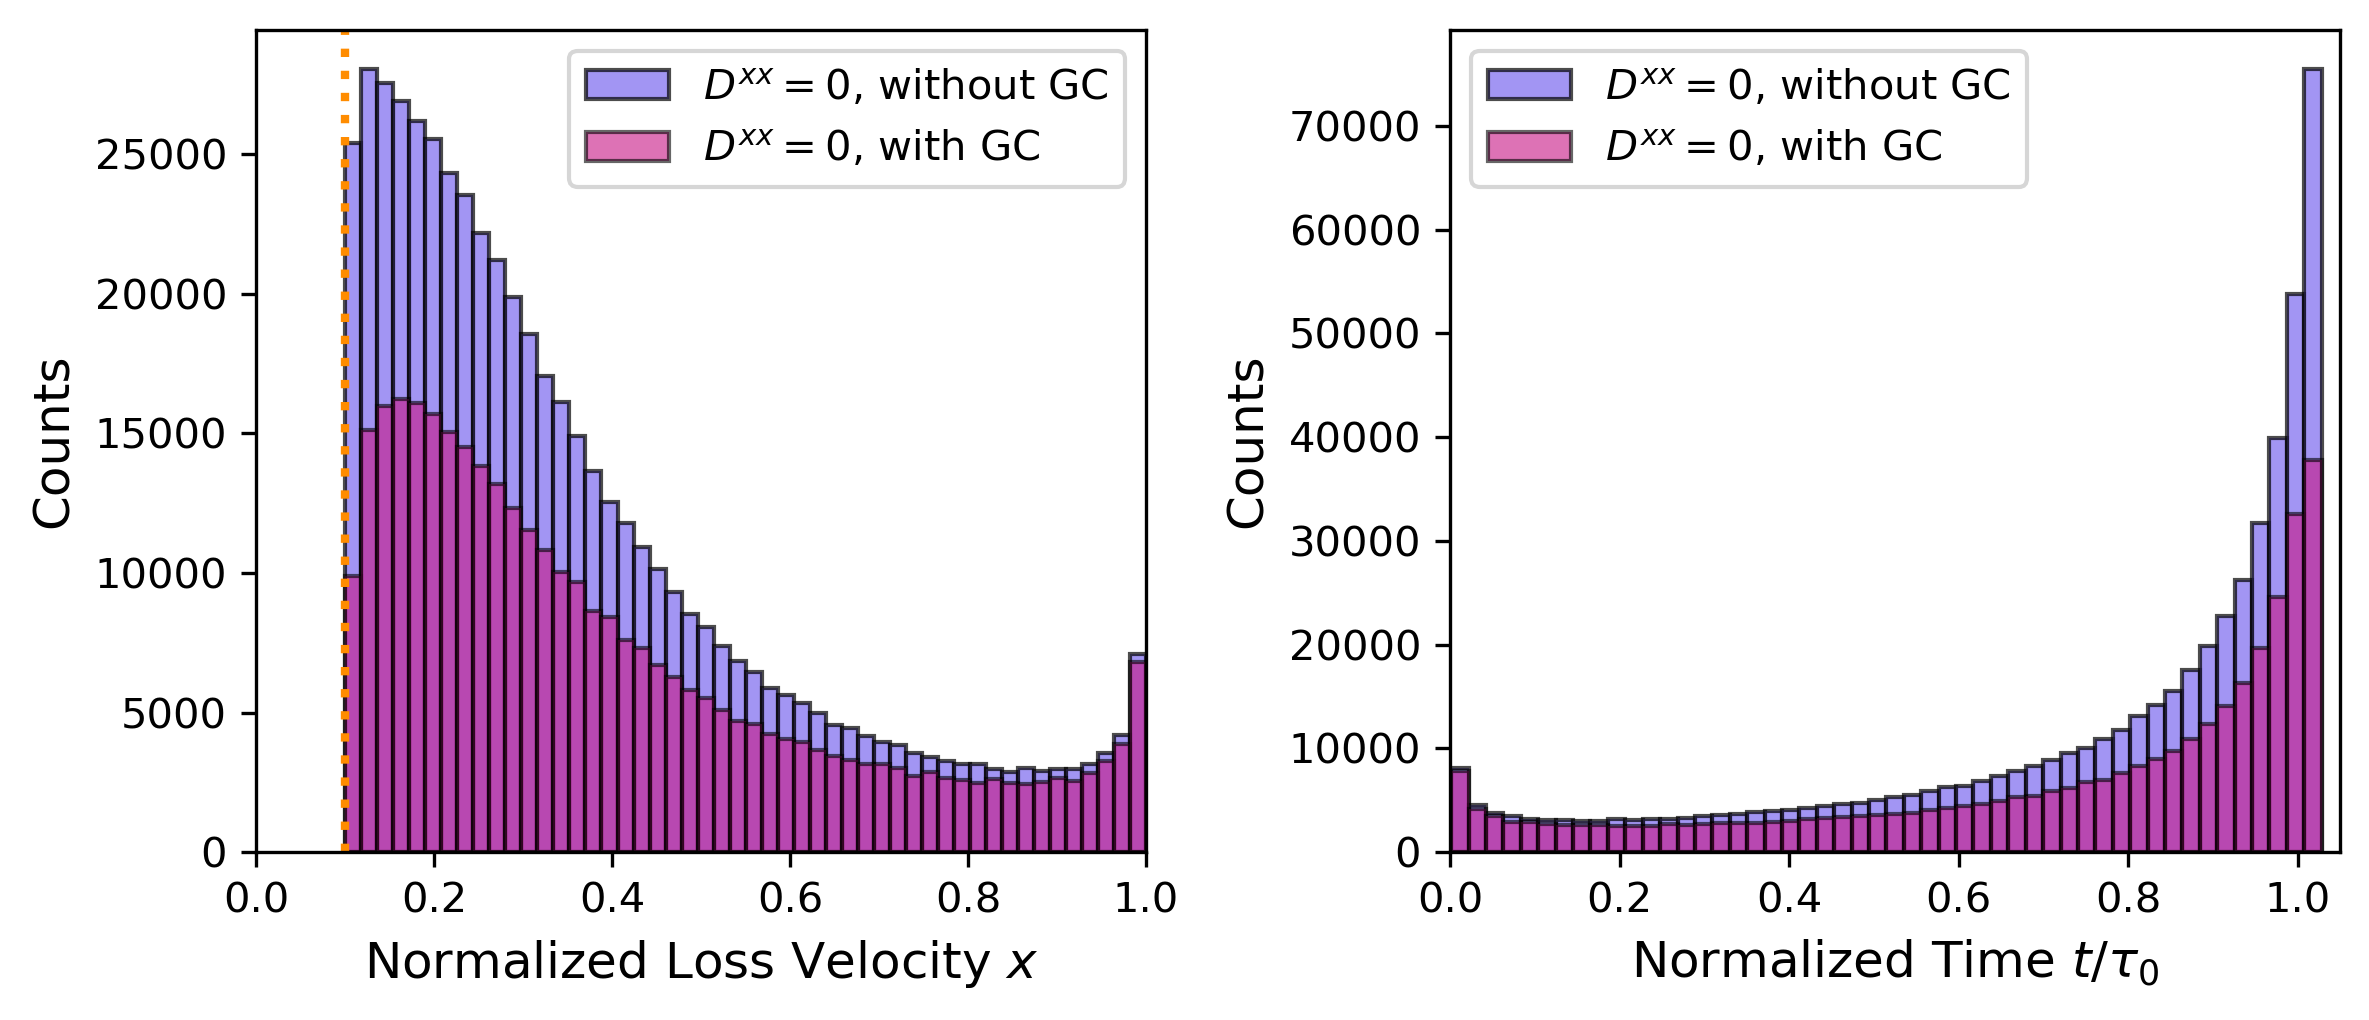

In [ ]:
# PLOT TOGETHER Dxx = 0 
filename_mesa = f'loss_data/{int(NUMPARTICLES)}/mesa_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
with open(filename_mesa, "rb") as f:
    loss_vel_mesa, loss_step_mesa = pickle.load(f)

filename_nopar = f'loss_data/{int(NUMPARTICLES)}/nopar_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
with open(filename_nopar, "rb") as f:
    loss_vel_nopar, loss_step_nopar = pickle.load(f)

cutoff = 0.999
bins = 50

mask_mesa, mask_nopar = loss_vel_mesa[:,0] <= cutoff, loss_vel_nopar[:,0] <= cutoff
print(loss_vel_mesa[mask_mesa].shape)
print(loss_vel_nopar[mask_nopar].shape)


plt.figure(figsize=(8,3.5), dpi=300)

plt.subplot(1, 2, 1)
plt.hist(loss_vel_mesa[mask_mesa][:,0], range=(0.1, 1), bins=bins, alpha=0.7, edgecolor='k', color='mediumslateblue', label=r'$D^{xx}=0$, without GC')
plt.hist(loss_vel_nopar[mask_nopar][:,0], range=(0.1, 1), bins=bins, alpha=0.6, edgecolor='k', color='mediumvioletred', label=r'$D^{xx}=0$, with GC')
plt.xlabel(r'Normalized Loss Velocity $x$', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.axvline(0.1, color='darkorange', linewidth=2, linestyle=':')
plt.xlim(0, 1)
# plt.ylim(0, 32500)
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.hist(loss_step_mesa[mask_mesa] * DT, bins=bins, alpha=0.7, color='mediumslateblue', edgecolor='black', label=r'$D^{xx}=0$, without GC')
plt.hist(loss_step_nopar[mask_nopar] * DT, bins=bins, alpha=0.6, color='mediumvioletred', edgecolor='black', label=r'$D^{xx}=0$, with GC')
plt.xlabel(r'Normalized Time $t/\tau_0$', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.xlim(0, 1.05)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


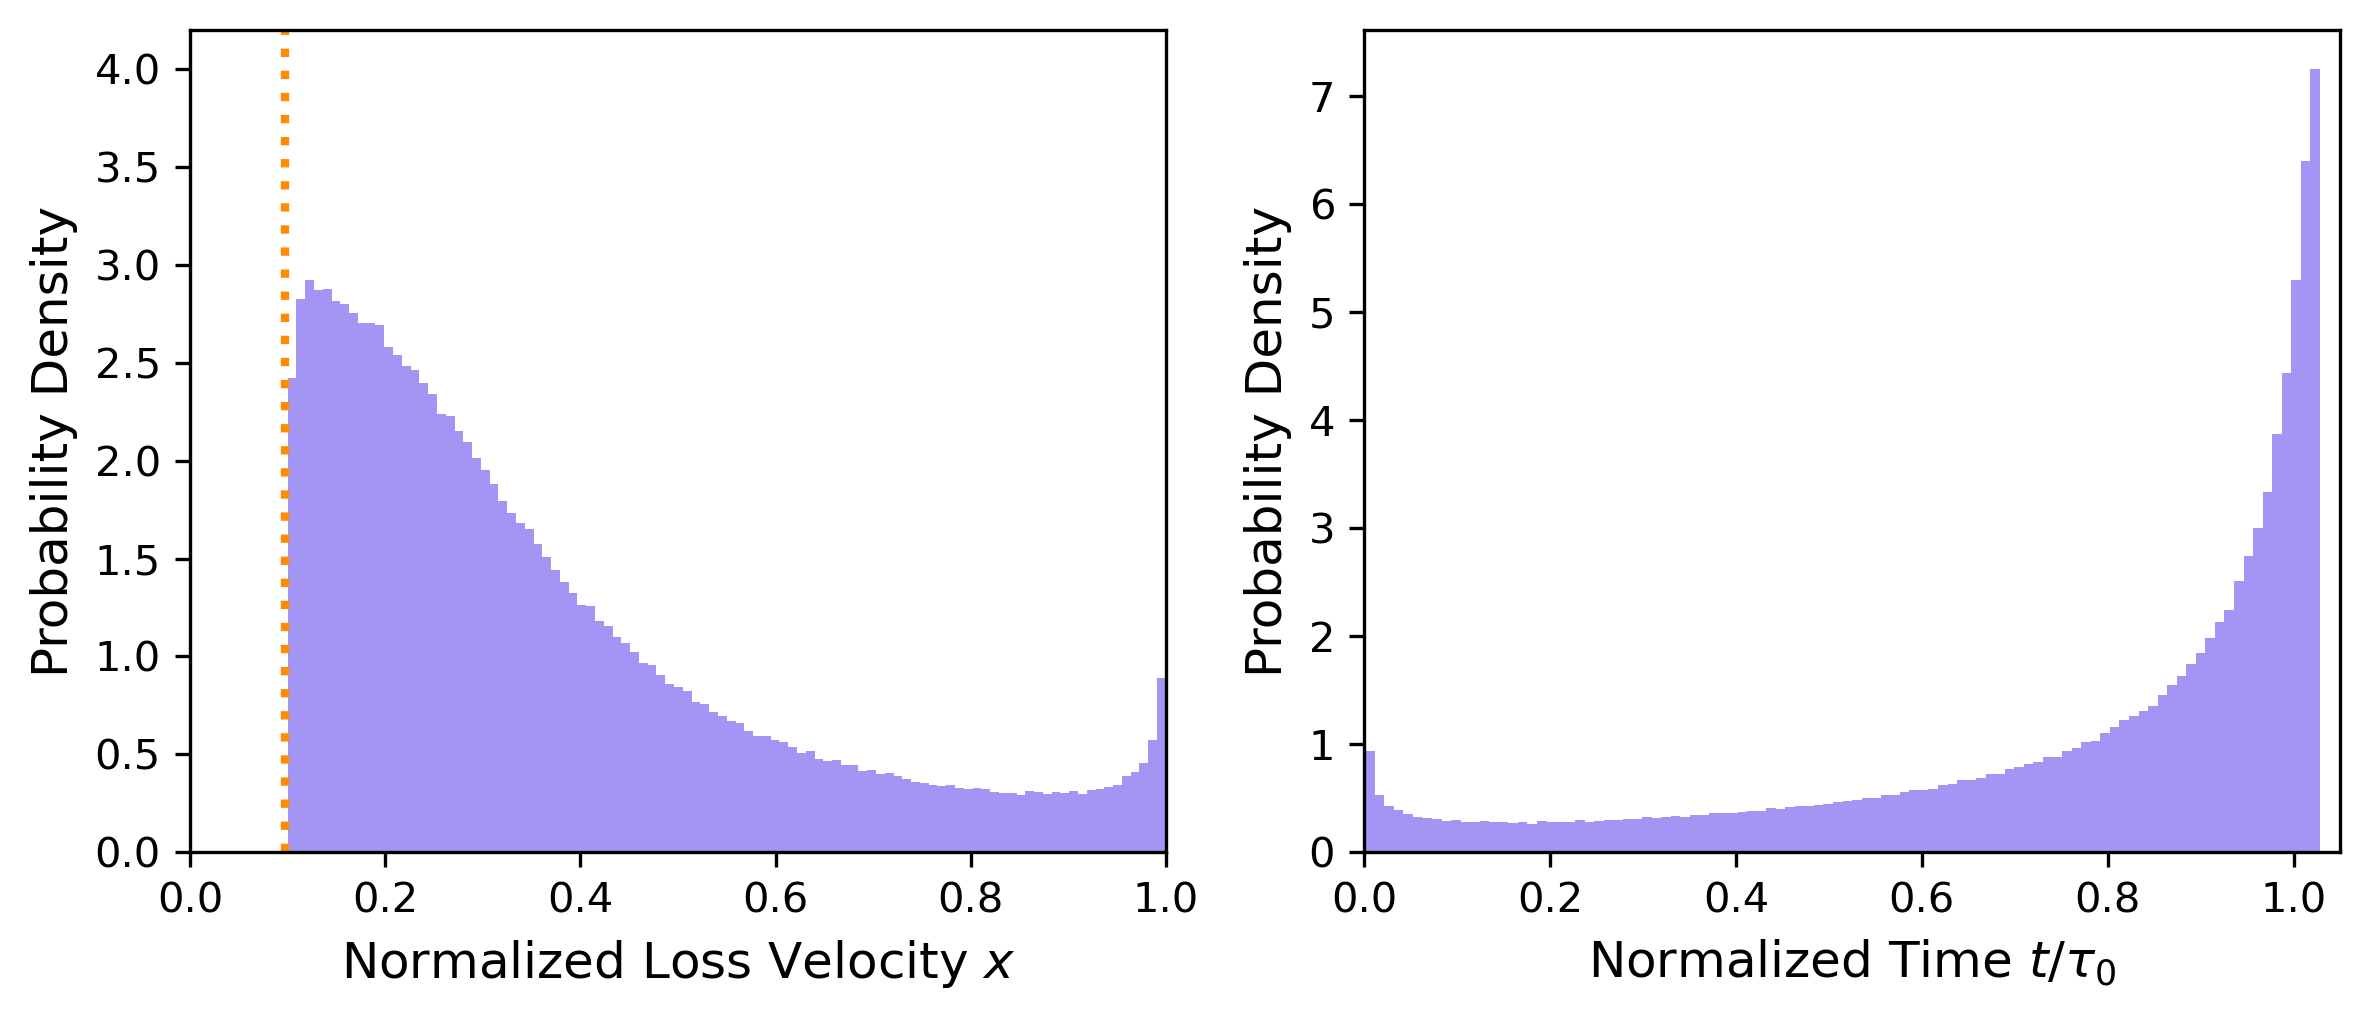

In [ ]:
plt.figure(figsize=(8,3.5), dpi=300)

bins=100

plt.subplot(1, 2, 1)
plt.hist(loss_vel_mesa[mask_mesa][:,0], range=(0.1, 1), density=True, bins=bins, alpha=0.7, color='mediumslateblue')
plt.xlabel(r'Normalized Loss Velocity $x$', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.axvline(0.097, color='darkorange', linewidth=2, linestyle=':')
plt.xlim(0, 1)
plt.ylim(0, 4.2)

plt.subplot(1, 2, 2)
plt.hist(loss_step_mesa[mask_mesa] * DT, bins=bins, density=True, alpha=0.7, color='mediumslateblue')
plt.xlabel(r'Normalized Time $t/\tau_0$', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.xlim(0, 1.05)

plt.tight_layout()
plt.show()

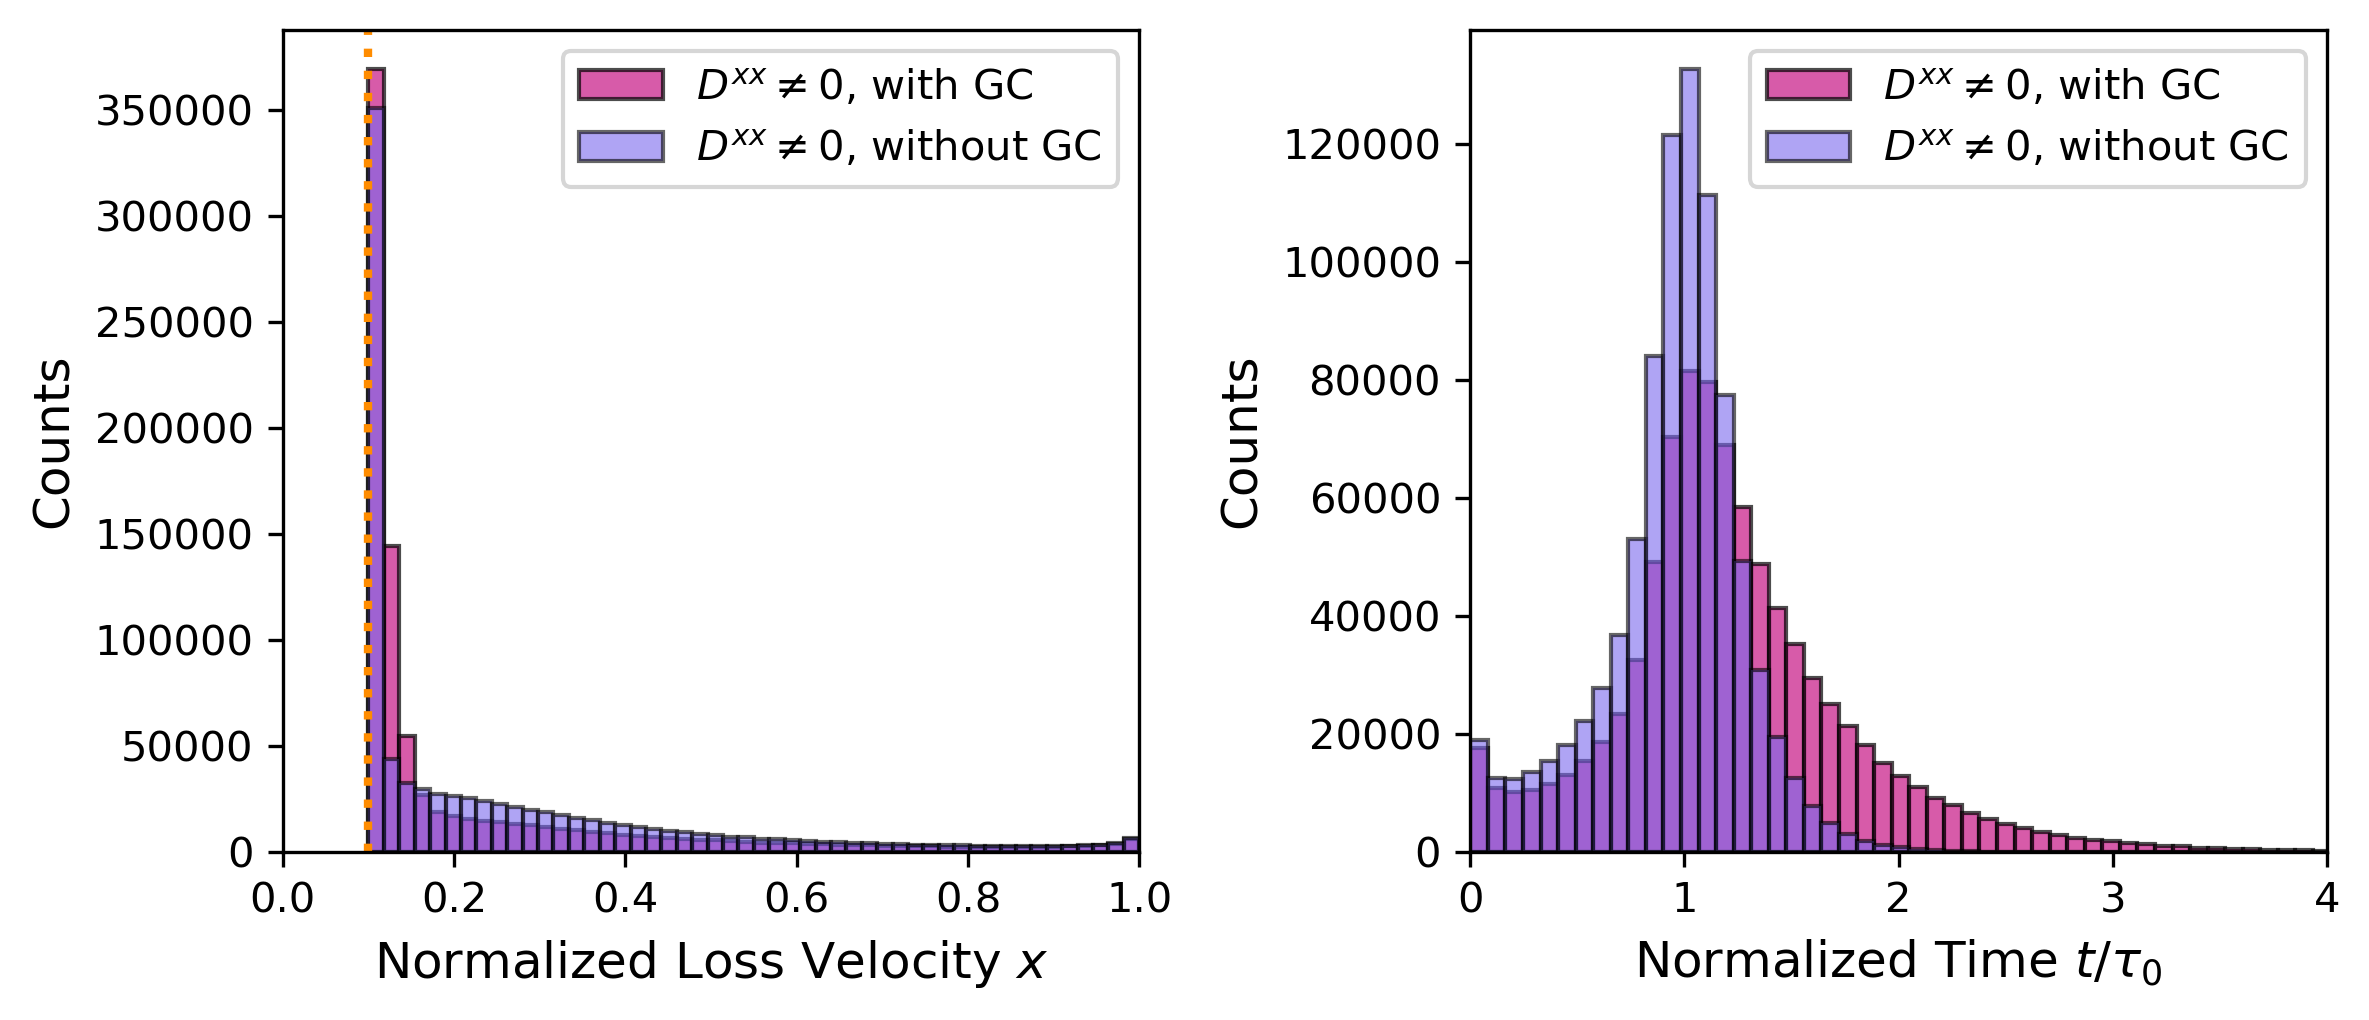

In [7]:
# PLOT TOGETHER Dxx =/= 0 
filename_full = f'loss_data/{int(NUMPARTICLES)}/full_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
with open(filename_full, "rb") as f:
    loss_vel_full, loss_step_full = pickle.load(f)

filename_nogeom = f'loss_data/{int(NUMPARTICLES)}/nogeom_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
with open(filename_nogeom, "rb") as f:
    loss_vel_nogeom, loss_step_nogeom = pickle.load(f)

cutoff = 0.999

mask_full, mask_nogeom = loss_vel_full[:,0] <= cutoff, loss_vel_nogeom[:,0] <= cutoff


plt.figure(figsize=(8,3.5), dpi=300)

plt.subplot(1, 2, 1)
plt.hist(loss_vel_full[mask_full][:,0], range=(0.1, 1), bins=50, alpha=0.7, color='mediumvioletred', edgecolor='black', label=r'$D^{xx}\neq0$, with GC')
plt.hist(loss_vel_nogeom[mask_nogeom][:,0], range=(0.1, 1), bins=50, alpha=0.6, color='mediumslateblue', edgecolor='black', label=r'$D^{xx}\neq0$, without GC')
plt.xlabel(r'Normalized Loss Velocity $x$', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.axvline(0.1, color='darkorange', linewidth=2, linestyle=':')
plt.xlim(0, 1)
# plt.yscale('log')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.hist(loss_step_full[mask_full] * DT, bins=50, alpha=0.7, range=(0,4.1), color='mediumvioletred', edgecolor='black', label=r'$D^{xx}\neq0$, with GC')
plt.hist(loss_step_nogeom[mask_nogeom] * DT, bins=50, range=(0,4.1), alpha=0.6, color='mediumslateblue', edgecolor='black', label=r'$D^{xx}\neq0$, without GC')
plt.xlabel(r'Normalized Time $t/\tau_0$', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.xlim(0, 4)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()